In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import os



In [4]:
train_dir = "../data/histo_split/train"
val_dir = "../data/histo_split/val"
test_dir = "../data/histo_split/test"


In [7]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)


Found 712 images belonging to 2 classes.
Found 152 images belonging to 2 classes.
Found 155 images belonging to 2 classes.


In [8]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 224, 224, 3)  0           ['normalization[0][0]']      

In [9]:
steps_per_epoch = train_gen.samples // BATCH_SIZE
validation_steps = val_gen.samples // BATCH_SIZE

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=5,
    callbacks=[early_stop],
    workers=1,
    use_multiprocessing=False,
    verbose=1
)


Epoch 1/5
44/44 [==============================] - 49s 985ms/step - loss: 0.6960 - accuracy: 0.5216 - val_loss: 0.6829 - val_accuracy: 0.5694
Epoch 2/5
44/44 [==============================] - 43s 986ms/step - loss: 0.6892 - accuracy: 0.5747 - val_loss: 0.6897 - val_accuracy: 0.5486
Epoch 3/5
44/44 [==============================] - 44s 1s/step - loss: 0.6979 - accuracy: 0.5144 - val_loss: 0.6906 - val_accuracy: 0.5486
Epoch 4/5
44/44 [==============================] - 50s 1s/step - loss: 0.6911 - accuracy: 0.5445 - val_loss: 0.7010 - val_accuracy: 0.5417
Epoch 5/5
44/44 [==============================] - 46s 1s/step - loss: 0.6908 - accuracy: 0.5647 - val_loss: 0.6894 - val_accuracy: 0.8681


In [11]:
model.save_weights("../models/efficientnet_histo_weights")
print("Model weights saved successfully!")


Model weights saved successfully!


In [13]:
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)


Found 155 images belonging to 2 classes.
10/10 [==============================] - 10s 984ms/step - loss: 0.6894 - accuracy: 0.9161
Test Accuracy: 0.9161290526390076


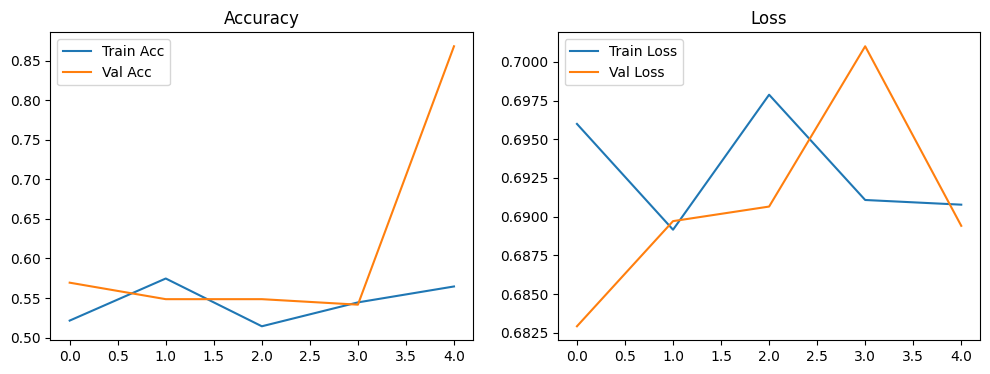

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()
